# Segmentation and Fudging

In [2]:
import os

# Set environment variables to disable multithreading as users
# will probably
# want to set the number of cores to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
#########################################################################
# Set TensorFlow print of log information
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

from anomaly.constants import GALAXY_LINES

from astroExplain.spectra.fudge import Fudge
from astroExplain.spectra.notebook import neighbors_explainer
from astroExplain.spectra.segment import SpectraSegmentation
from astroExplain.spectra.neighbors import SpectraNeighbors
from astroExplain.spectra.notebook import spectrum_in_segments

from autoencoders.ae import AutoEncoder
from anomaly.utils import specobjid_to_idx

from sdss.metadata import MetaData
from sdss.utils.managefiles import FileDirectory

meta = MetaData()


# Custom functions

## Figures

### Neigbors

In [4]:
def plot_neighbor(
    wave_nm,
    spectrum,
    neighbor,
    rec_neighbor,
    figsize: tuple = (10, 9),
):

    fig, axs = plt.subplots(
        2, 1, 
        sharex=True,
        sharey=True,
        figsize=(12, 10),
    )
    
    c_orig = 'gray'
    c_pert = '#004488' # Deep blue
    c_rec = '#B22222'  # Crimson red

    # --- UPPER PANEL: The Perturbation ---
    axs[0].plot(
        wave_nm, spectrum, label='Original',
        color=c_orig, alpha=0.6, linewidth=1.
    )

    axs[0].plot(
        wave_nm, neighbor, label='Perturbation',
        color=c_pert, linewidth=1.2
    )
    
    # --- LOWER PANEL: The Reconstruction ---
    axs[1].plot(
        wave_nm, neighbor, label='Perturbation',
        color=c_pert, alpha=0.4, linewidth=2.2
    )
    
    axs[1].plot(
        wave_nm, rec_neighbor, label='Reconstruction',
        color=c_rec, linewidth=1.2
    )

    # 
    axs[1].set_xlabel(r"$\lambda$ [nm]")
    for ax in axs:
        ax.minorticks_on()
        
    return fig, axs

### Segmentation

In [5]:
def segment_spec(
    wave: np.array,
    spectrum: np.array,
    segmentation: np.array,
    number_segments: int = 100,
):

    segmenter = SpectraSegmentation()

    if segmentation == "uniform":

        segmentation_function = segmenter.uniform
        segmentation = "Uniform segmentation with"

    elif segmentation == "kmeans":

        segmentation_function = segmenter.kmeans
        segmentation = "SLIC segmentation with"

    else:
        print(f"Segmenation {segmentation} not defined")
        sys.exit()

    segments = segmentation_function(spectrum, number_segments=number_segments)
    segmented_spectrum = spectrum_in_segments(spectrum, segments)

    number_segments = np.unique(segments).size
    print(f"Number of segments: {number_segments}")

    return segments, segmented_spectrum

# Config

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape[0]

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## Scores

### Residulas

In [8]:
bin_id = 'bin_03'
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

# add sublclass
score_rank_df['subclass'] = final_meta_df.loc[score_rank_df.index].subClass

## Models

### VAE

In [9]:
bin_id = 'bin_03'
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

# Segmentation

In [10]:
n_segments = 63
width_segment = n_wave//n_segments
tail_width_segment = n_wave%n_segments
print(
    f"n_wave: {n_wave}\n"
    f"n_segments: {n_segments}\n"
    f"width_segment: {width_segment}\n"
    f"tail_width_segment: {tail_width_segment}\n"
    f"n waves no tail: {n_segments*width_segment}"
)

n_wave: 3773
n_segments: 63
width_segment: 59
tail_width_segment: 56
n waves no tail: 3717


## Data

In [11]:
n_spec = score_rank_df.shape[0]
normal_mask = score_rank_df['rank_mse'] == n_spec-1 

score_rank_df.loc[normal_mask].index[0]

2568244270221780992

In [12]:
n_segments = 63
print(f"N segments: {n_segments}")
objid_dict = {
    'normal': 2568244270221780992,
    # 'Filter + Trim SE': 2191010072388200448,
    'Trim SE': 312016418084251648,
    # 'Filter SE':2203468363479410688, 
}
print(score_rank_df.loc[objid_dict.values(), ['subclass']])
print('-'*50)
# ------------------------------------------------------------------
spec_dict = {}

for key, specobjid in objid_dict.items():

    idx_spec = specobjid_to_idx(specobjid, idx_id_spec)
    spec = spectra[idx_spec]
    spec_dict[key] = spec
# ------------------------------------------------------------------
segmented_uniform_dict = {}
segmented_kmeans_dict = {}

for key, spec in spec_dict.items():

    segments_uniform, segmented_spectrum_uniform = segment_spec(
        wave=wave_nm,
        spectrum=spec,
        segmentation="uniform",
        number_segments=n_segments,
    )

    segmented_uniform_dict[key] = segmented_spectrum_uniform

    segments_kmeans, segmented_spectrum_kmeans = segment_spec(
        wave=wave_nm,
        spectrum=spec,
        segmentation="kmeans",
        number_segments=n_segments,
    )

    segmented_kmeans_dict[key] = segmented_spectrum_kmeans

N segments: 63
                        subclass
specobjid                       
2568244270221780992          NaN
312016418084251648   STARFORMING
--------------------------------------------------
Number of segments: 64
Number of segments: 30
Number of segments: 64
Number of segments: 14


## Figure

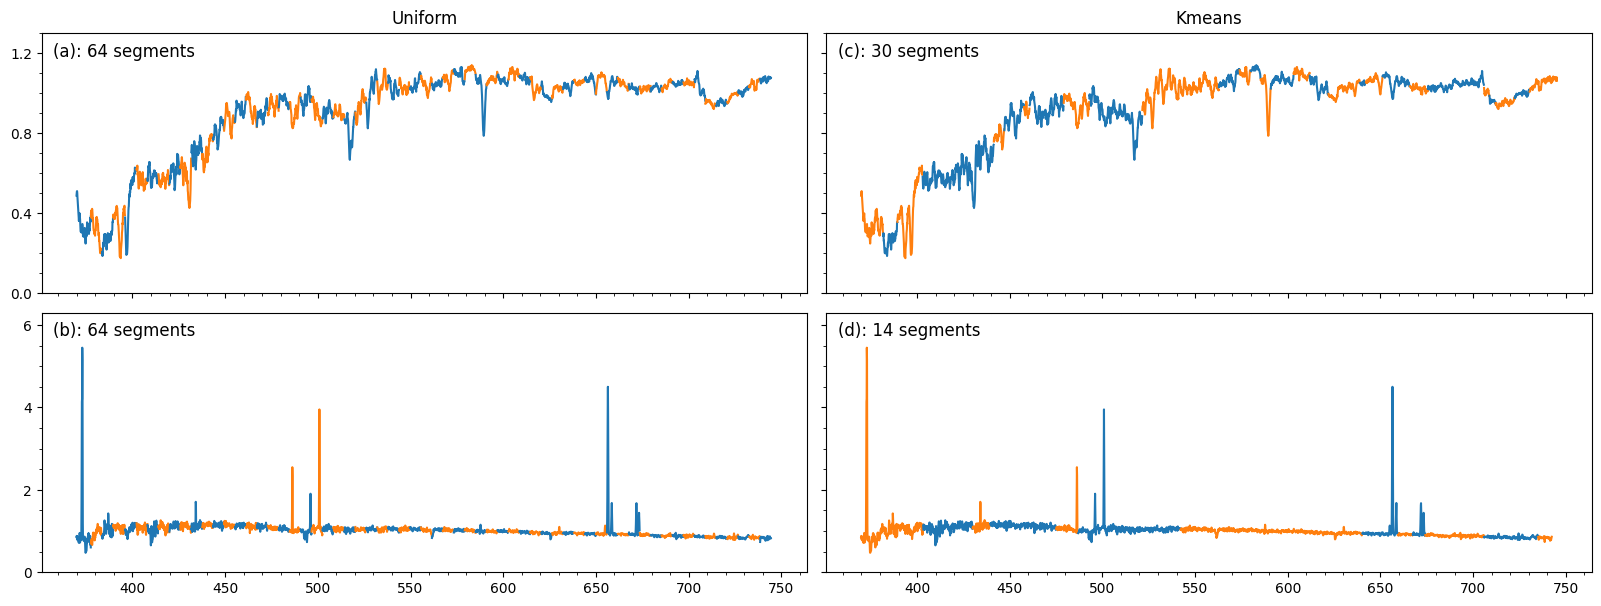

In [13]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    sharey='row',
    figsize=(20, 7)
)
# [Muted Blue, Muted Orange]
colors = ['#1f77b4', '#ff7f0e']

plot_configs = [
    (axs[0, 0], segmented_uniform_dict['normal'], '(a)'),
    (axs[1, 0], segmented_uniform_dict['Trim SE'], '(b)'),
    (axs[0, 1], segmented_kmeans_dict['normal'],  '(c)'),
    (axs[1, 1], segmented_kmeans_dict['Trim SE'], '(d)')
]

for ax, segments, panel in plot_configs:

    for color_id, segment in enumerate(segments):
        
        ax.plot(wave_nm, segment, color=colors[color_id % 2])

    ax.minorticks_on()

    n_segments = segments.shape[0]

    ax.text(
    0.015, 0.93,
        f"{panel}: {n_segments} segments",
        horizontalalignment="left", verticalalignment="center",
        transform=ax.transAxes,
        fontsize=12
    )
# ------------------------------------------------------------
# set y lims
y_lim = (0, 1.3)
y_ticks = [0, 0.4, 0.8, 1.2]
axs[0, 0].set_ylim(y_lim)
axs[0, 0].set_yticks(y_ticks)

y_lim = (0, 6.3)
y_ticks = [0, 2, 4 , 6]
axs[1, 0].set_ylim(y_lim)
axs[1, 0].set_yticks(y_ticks)
# ------------------------------------------------------------
# Add titles ONLY to the first row (index 0)
axs[0, 0].set_title("Uniform", fontsize=12, pad=7)
axs[0, 1].set_title("Kmeans", fontsize=12, pad=7)
# ------------------------------------------------------------
plt.subplots_adjust(
    hspace=0.075,
    wspace=0.025
)

# fig.savefig(
#     f"{ch_5_dir}/lime/spec_segmentations.pdf",
#     bbox_inches='tight'
# )

# Perturbation
```python
fudge_parameters = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "with_mean",
    # scale
    "scale_factor": 0.8,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 0.2,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 1,
}
```

## Mean

In [ ]:
fudge_parameters = {
    "kind_of_fudge": "with_mean",
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 1,
}

n_segments = 63

neighbors_with_mean_kmeans = neighbors_explainer(
    number_samples=100,
    spectrum=spec_dict['normal'],
    segmentation='kmeans',
    number_segments=n_segments,
    fudge_parameters=fudge_parameters,
)

neighbors_with_mean_uniform = neighbors_explainer(
    number_samples=100,
    spectrum=spec_dict['normal'],
    segmentation='uniform',
    number_segments=n_segments,
    fudge_parameters=fudge_parameters,
)

rec_neighbors_with_mean_kmeans = ae_model.reconstruct(
    neighbors_with_mean_kmeans
)
rec_neighbors_with_mean_uniform = ae_model.reconstruct(
    neighbors_with_mean_uniform
)


Number of segments: 30
Number of segments: 63


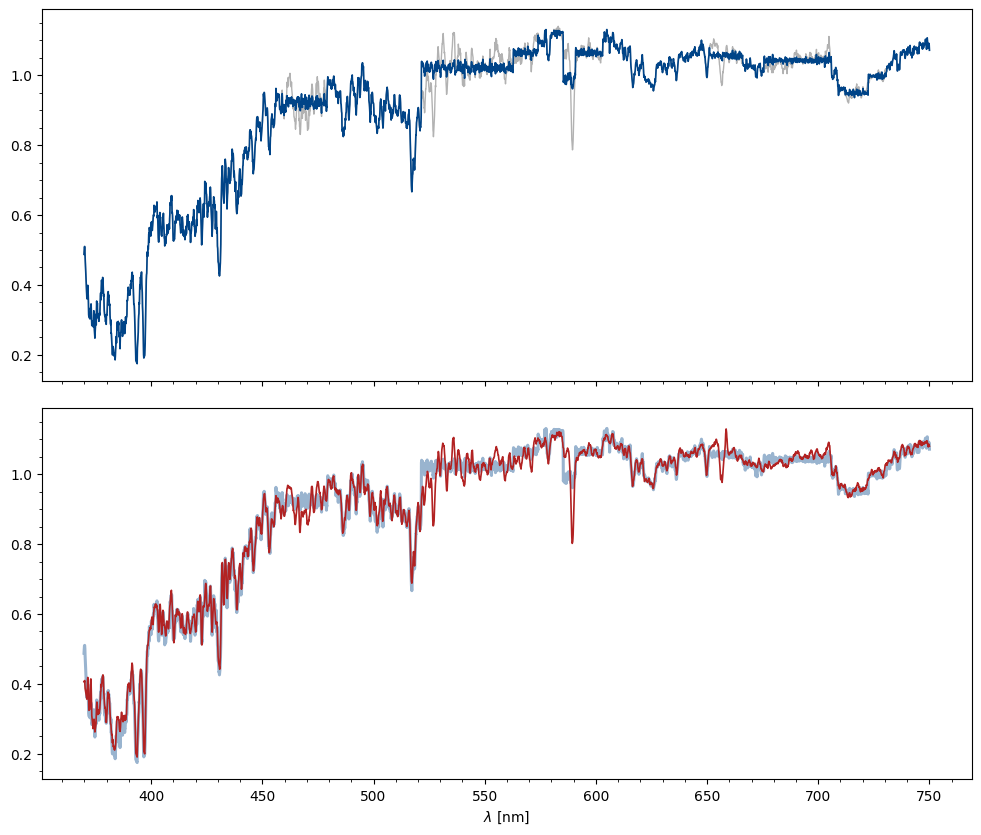

In [18]:
neighbor_id = 4
# neighbor_id = 3
# neighbor_id = 2
neighbors = neighbors_with_mean_kmeans
rec_neighbors = rec_neighbors_with_mean_kmeans

fig, axs = plot_neighbor(
    wave_nm,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    rec_neighbor=rec_neighbors[neighbor_id],
)
plt.subplots_adjust(
    hspace=0.075,
    wspace=0.025
)

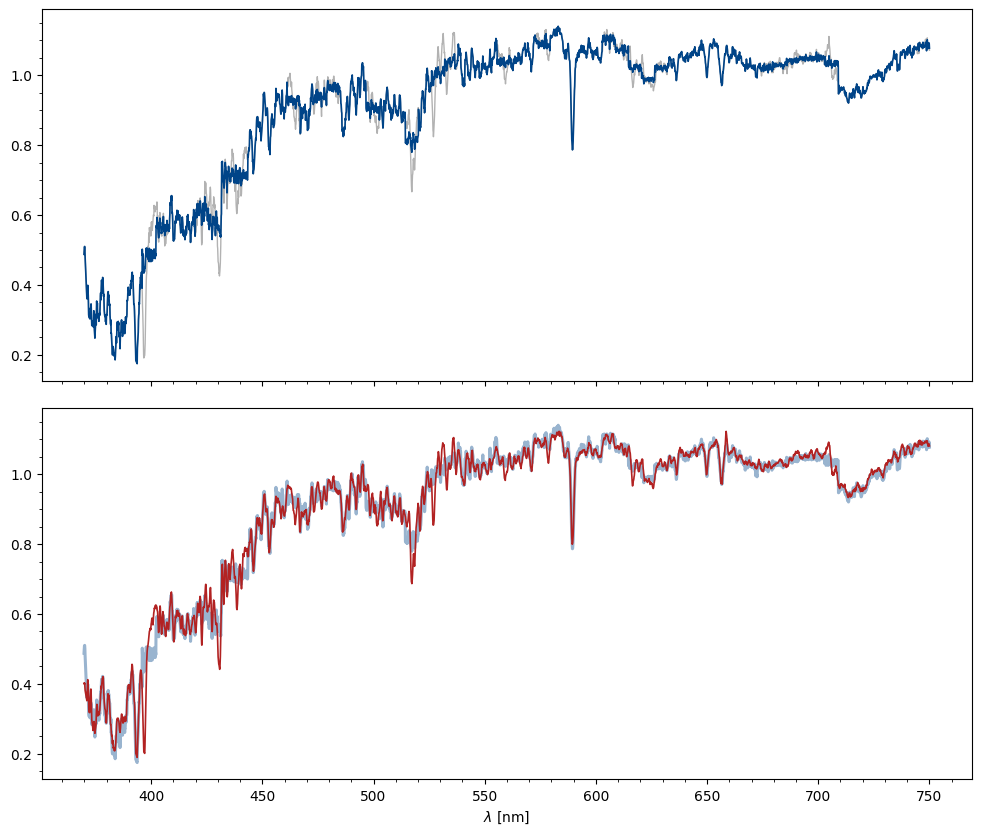

In [19]:
# neighbor_id = 2
neighbor_id = 1
neighbors = neighbors_with_mean_uniform
rec_neighbors = rec_neighbors_with_mean_uniform

fig, axs = plot_neighbor(
    wave_nm,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    rec_neighbor=rec_neighbors[neighbor_id],
)
plt.subplots_adjust(
    hspace=0.075,
    wspace=0.025
)

## Scale

In [20]:
fudge_parameters = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 1,
}

n_segments = 63

neighbors_scale_kmeans = neighbors_explainer(
    number_samples=100,
    spectrum=spec_dict['normal'],
    segmentation='kmeans',
    number_segments=n_segments,
    fudge_parameters=fudge_parameters,
)


neighbors_scale_uniform = neighbors_explainer(
    number_samples=100,
    spectrum=spec_dict['normal'],
    segmentation='uniform',
    number_segments=n_segments,
    fudge_parameters=fudge_parameters,
)


rec_neighbors_scale_kmeans = ae_model.reconstruct(
    neighbors_scale_kmeans
)

rec_neighbors_scale_uniform = ae_model.reconstruct(
    neighbors_scale_uniform
)

Number of segments: 30
Number of segments: 63


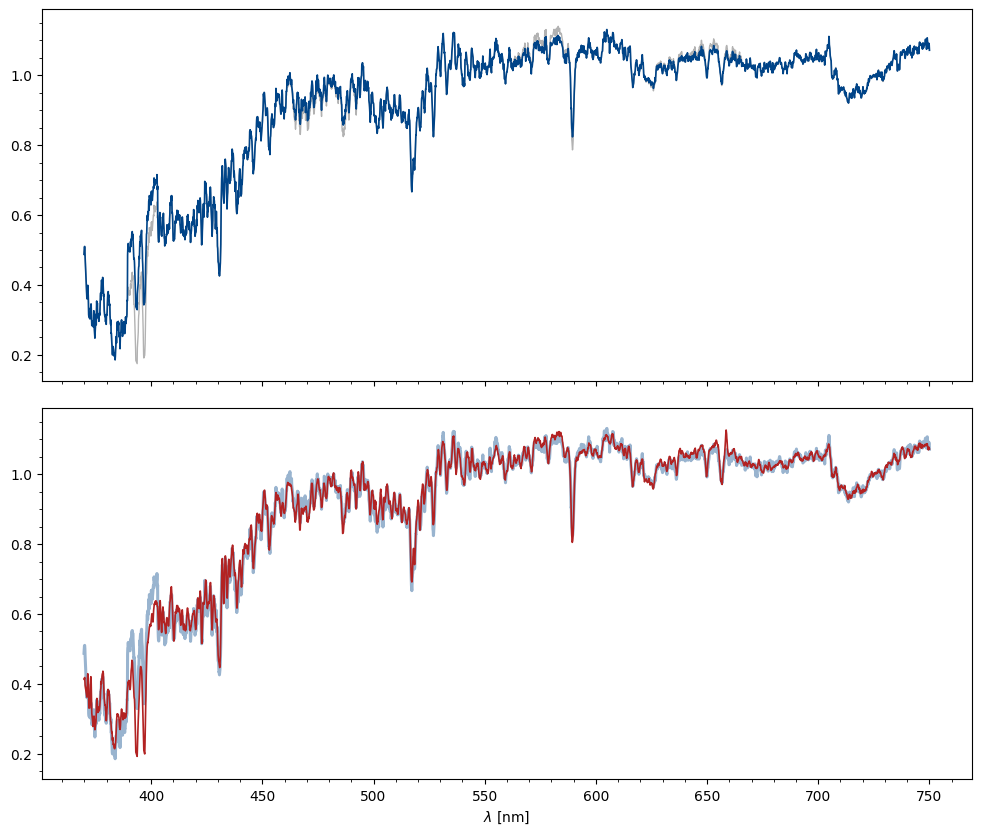

In [ ]:
# neighbor_id = 3
neighbor_id = 2
neighbors = neighbors_scale_kmeans
rec_neighbors = rec_neighbors_scale_kmeans

fig, axs = plot_neighbor(
    wave_nm,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    rec_neighbor=rec_neighbors[neighbor_id],
)
plt.subplots_adjust(
    hspace=0.075,
    wspace=0.025
)

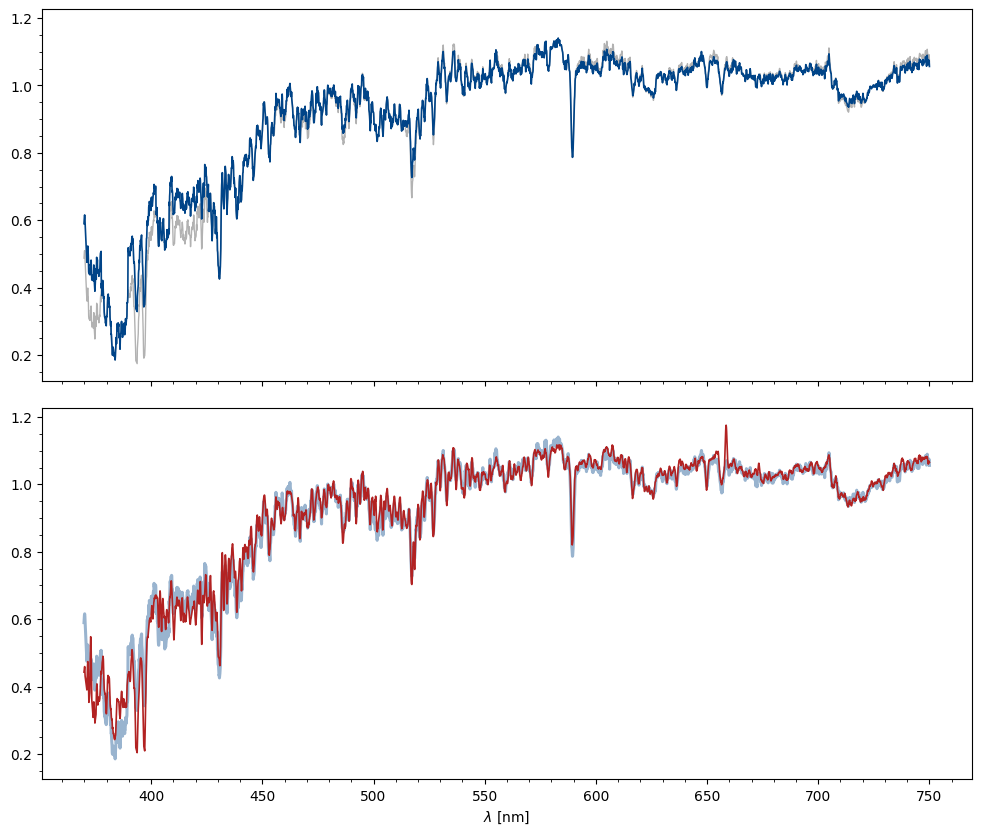

In [ ]:
neighbor_id = 2
neighbors = neighbors_scale_uniform
rec_neighbors = rec_neighbors_scale_uniform

fig, axs = plot_neighbor(
    wave_nm,
    spectrum=neighbors[0],
    neighbor=neighbors[neighbor_id],
    rec_neighbor=rec_neighbors[neighbor_id],
)
plt.subplots_adjust(
    hspace=0.075,
    wspace=0.025
)

## Fig - Selection

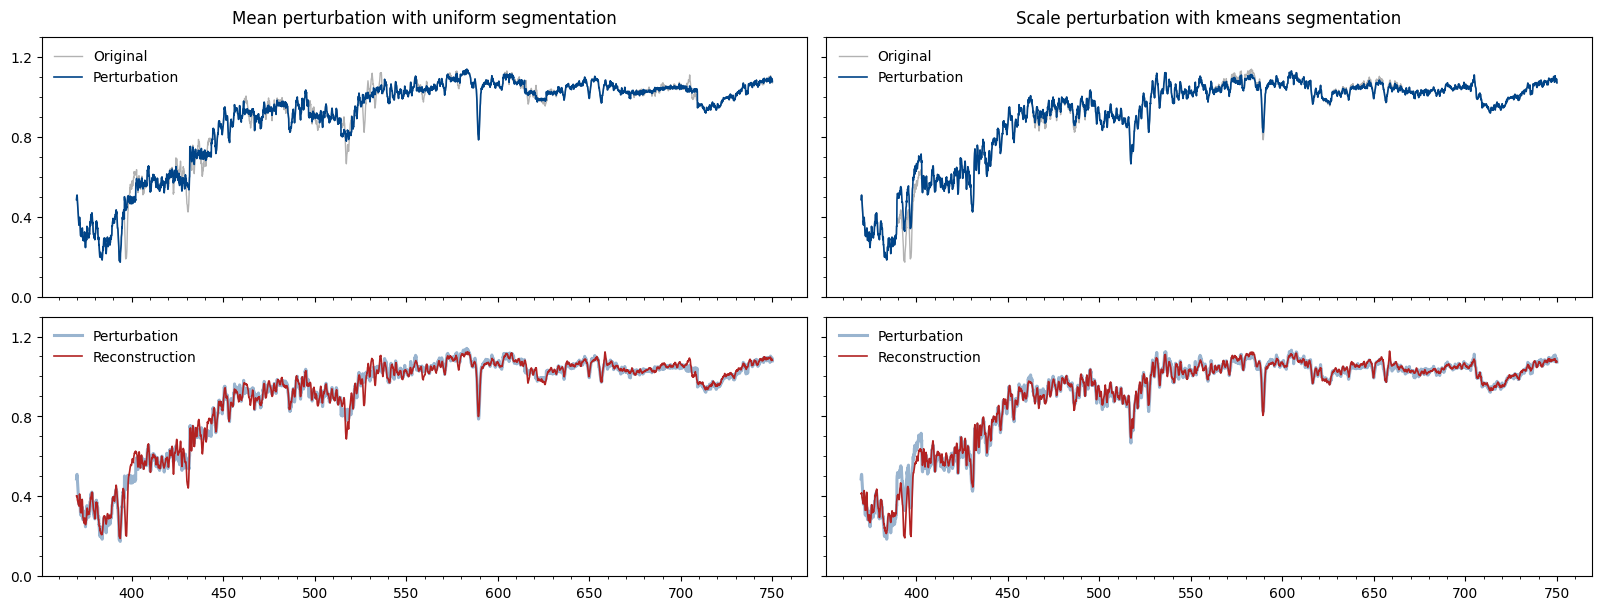

In [41]:
spec = spec_dict['normal']
# 
neighbor_id = 1
pert_with_mean_uniform_spec = neighbors_with_mean_uniform[neighbor_id]
rec_pert_with_mean_uniform_spec = rec_neighbors_with_mean_uniform[neighbor_id]
# 
neighbor_id = 2
pert_scale_kmeans_spec = neighbors_scale_kmeans[neighbor_id]
rec_pert_scale_kmeans_spec = rec_neighbors_scale_kmeans[neighbor_id]

fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    sharey=True,
    figsize=(20, 7)
)

c_orig = 'gray'
c_pert = '#004488' # Deep blue
c_rec = '#B22222'  # Crimson red

axs[0, 0].plot(
    wave_nm, spec, label='Original',
    color=c_orig, alpha=0.6, linewidth=1.
)

axs[0, 0].plot(
    wave_nm, pert_with_mean_uniform_spec, label='Perturbation',
    color=c_pert, linewidth=1.2
)

axs[1, 0].plot(
    wave_nm, pert_with_mean_uniform_spec, label='Perturbation',
    color=c_pert, alpha=0.4, linewidth=2.2
)

axs[1, 0].plot(
    wave_nm, rec_pert_with_mean_uniform_spec, label='Reconstruction',
    color=c_rec, linewidth=1.2
)
# ----------------------------------

axs[0, 1].plot(
    wave_nm, spec, label='Original',
    color=c_orig, alpha=0.6, linewidth=1.
)

axs[0, 1].plot(
    wave_nm, pert_scale_kmeans_spec, label='Perturbation',
    color=c_pert, linewidth=1.2
)

axs[1, 1].plot(
    wave_nm, pert_scale_kmeans_spec, label='Perturbation',
    color=c_pert, alpha=0.4, linewidth=2.2
)

axs[1, 1].plot(
    wave_nm, rec_pert_scale_kmeans_spec, label='Reconstruction',
    color=c_rec, linewidth=1.2
)

# --------------------
# set y lims
y_lim = (0, 1.3)
y_ticks = [0, 0.4, 0.8, 1.2]
axs[0, 0].set_ylim(y_lim)
axs[0, 0].set_yticks(y_ticks)
# ---------------------------------------------------
for ax in axs.flatten():
    ax.legend(loc='upper left', fontsize=10, frameon=False)
    ax.minorticks_on()
# ------------------------------------------------------------
# Add titles ONLY to the first row (index 0)
axs[0, 0].set_title(
    "Mean perturbation with uniform segmentation",
    fontsize=12, pad=10
)
axs[0, 1].set_title(
    "Scale perturbation with kmeans segmentation",
    fontsize=12, pad=10
)
# ------------------------------------------------------------
plt.subplots_adjust(
    hspace=0.075,
    wspace=0.025
)

fig.savefig(
    f"{ch_5_dir}/lime/spec_perturbation.pdf",
    bbox_inches='tight'
)